# Exercise 2.1: Exploratory analysis of the transformer dataset

This notebook works in Python and uses `transformer_data.csv` as requested.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

data_path = Path("../transformer_data.csv")
df = pd.read_csv(data_path)

df.head()

,time,Y,Ta,S,I
0,1,23.496733,7.083333,0.0,15.899541
1,2,22.720333,7.116667,0.0,15.861768
2,3,22.052700,7.216667,0.0,16.121469
3,4,21.538050,7.250000,0.0,15.447628
4,5,20.995033,7.316667,0.0,16.258319


In [2]:
summary = df[["Y", "Ta", "S", "I"]].describe().T
summary

,count,mean,std,min,25%,50%,75%,max
Y,168.0,27.650595,5.455816,19.828583,23.246383,26.066717,32.201554,38.923850
Ta,168.0,10.023115,2.916687,4.516667,7.866667,9.750000,12.000000,17.466667
S,168.0,214.432540,259.451647,0.000000,0.000000,65.416667,410.250000,755.833333
I,168.0,18.179092,3.662521,14.386027,15.635851,16.367102,21.212430,25.362786


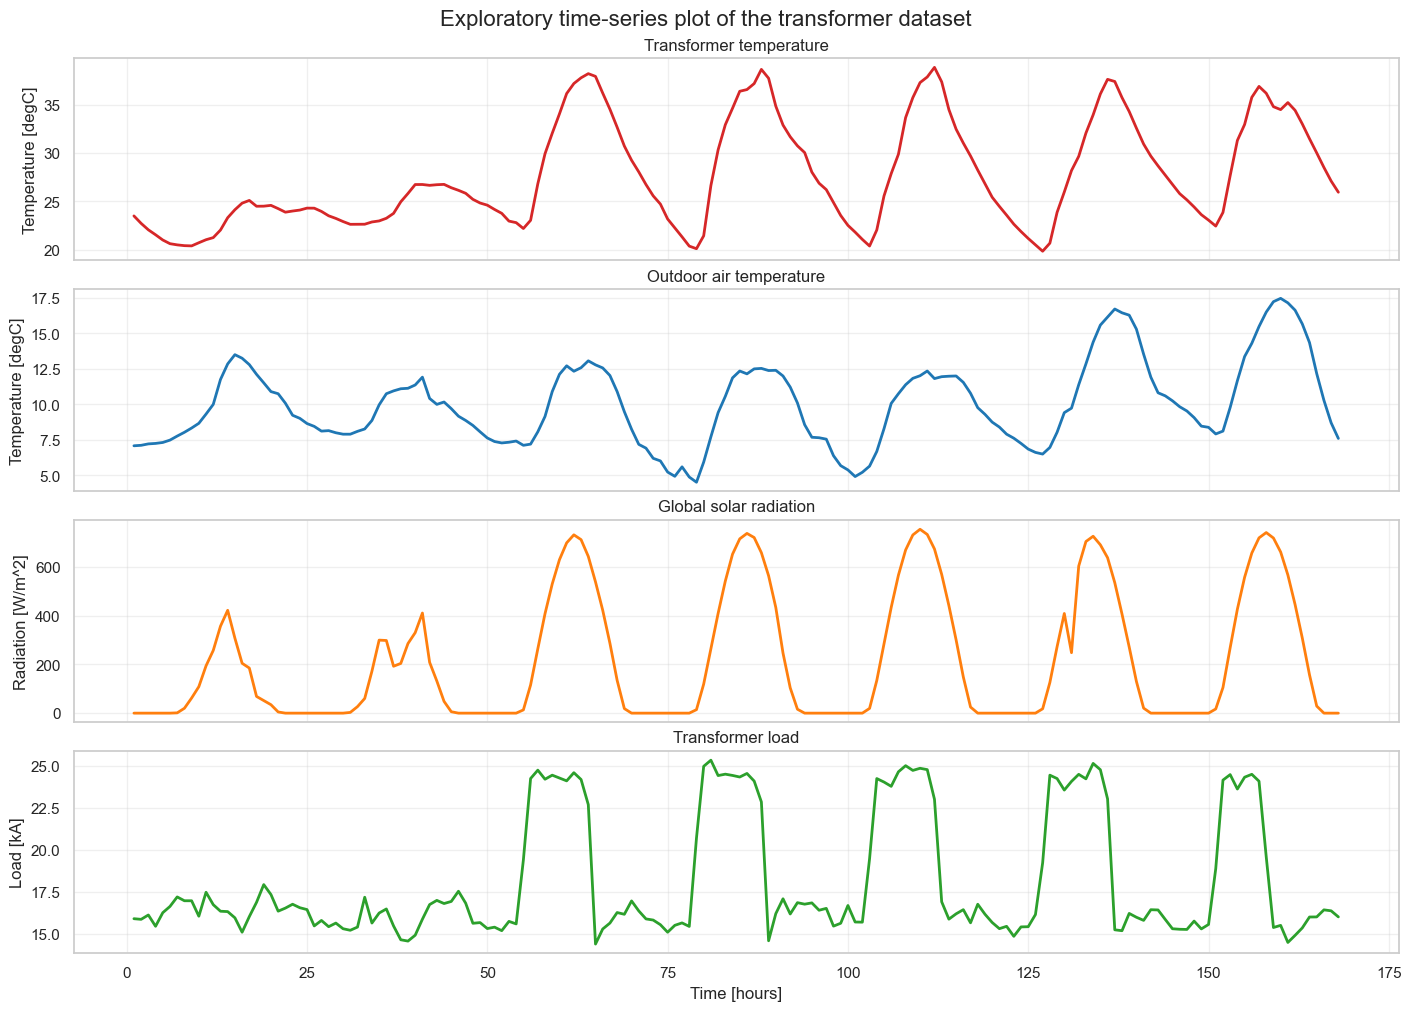

In [3]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True, constrained_layout=True)

series_config = [
    ("Y", "Transformer temperature", "tab:red", "Temperature [degC]"),
    ("Ta", "Outdoor air temperature", "tab:blue", "Temperature [degC]"),
    ("S", "Global solar radiation", "tab:orange", "Radiation [W/m^2]"),
    ("I", "Transformer load", "tab:green", "Load [kA]"),
]

for ax, (column, title, color, ylabel) in zip(axes, series_config):
    ax.plot(df["time"], df[column], color=color, linewidth=2)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Time [hours]")
fig.suptitle("Exploratory time-series plot of the transformer dataset", fontsize=16)
plt.show()

In [4]:
corr = df[["Y", "Ta", "S", "I"]].corr()
corr

,Y,Ta,S,I
Y,1.000000,0.778520,0.795264,0.384675
Ta,0.778520,1.000000,0.712500,0.162654
S,0.795264,0.712500,1.000000,0.631766
I,0.384675,0.162654,0.631766,1.000000


## Discussion

- The transformer temperature `Y` shows a clear repeating daily pattern with smooth rises and falls over time.
- `Y` tends to be high when both outdoor temperature `Ta` and solar radiation `S` are high, which suggests strong weather-related forcing.
- The relationship with `Ta` and `S` appears stronger than with load `I` in a same-time visual comparison.
- In this dataset, the sample correlations with `Y` are about `0.78` for `Ta`, `0.80` for `S`, and `0.38` for `I`.
- A practical modeling implication is that the state-space model should include exogenous effects from ambient conditions and may also need to account for thermal inertia, since the temperature evolves more smoothly than the inputs.